# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Movielens data querying and analysis using NoSQL Database

## Problem Statement

Using the Cassandra NoSQL database, explore the **Movielens** dataset and build a movie recommendation engine

## Learning Objectives

At the end of the mini-project, you will be able to :

* understand the concepts of NoSQL platforms
* implement the database connectivity using Cassandra
* create and insert data to the database 
* perform querying, retrieving and analyzing the data from database

### Dataset

The dataset chosen for this mini-project is [Movielens Dataset](https://movielens.org/). The dataset describes movies and ratings from Movielens. It contains movies from year 1919 to 2000 of total 3883 movies. There are 6040 users who have rated one or more than one movie of total 1000209 ratings collected. Movielens is maintained by members of GroupLens Research at the University of Minnesota. There are 3 datasets given, and they are:

1. `data_movie.csv` that contains movies information:

* MovieId
* Title
* Genres

2. `data_rating.csv` that contains ratings of movies by users:

* UserId
* MovieId
* Rating

3. `data_users.csv` that contains users information:

* UserId
* Age
* Gender

## Information

#### NoSQL platforms

A NoSQL database provides a mechanism for storage and retrieval of data that is modeled in a form other than the tabular relations used in relational databases.

**Cassandra** 

Apache Cassandra is a free and open-source, distributed, wide-column store, NoSQL database management system designed to handle large amounts of data across many commodity servers, providing high availability with no single point of failure. It is a NOSQL database developed by Facebook. It is a great database that allows you to effectively run queries on large amount of structured and semi structured data.

To know when you have to choose Cassandra as your database of choice, you need to have an understanding of CAP Theorem.

CAP theorem states that it is impossible for a distributed system to satisfy all three of these guarantees together, you need to leave one out.

- C is Consistency, means all nodes have the same data at the same time
- P is partition tolerance, means that in case of failure the system continues to operate
- A is availability , make sure every request receives a response

![img](https://developer.ibm.com/developer/default/tutorials/ba-set-up-apache-cassandra-architecture/images/figure1.png)

### Components of Cassandra

There are following components in the Cassandra

![img](https://www.guru99.com/images/cassandra/021116_0524_CassandraAr1.png)

**Node**
Node is the place where data is stored. It is the basic component of Cassandra.

**Data Center**
A collection of nodes are called data center. Many nodes are categorized as a data center.

**Cluster**
The cluster is the collection of many data centers.

**Commit Log**
Every write operation is written to Commit Log. Commit log is used for crash recovery.

**Mem-table**
After data written in Commit log, data is written in Mem-table. Data is written in Mem-table temporarily.

**SSTable**
When Mem-table reaches a certain threshold, data is flushed to an SSTable disk file.

### Data Replication

As hardware problem can occur or link can be down at any time during data process, a solution is required to provide a backup when the problem has occurred. So data is replicated for assuring no single point of failure.

Cassandra places replicas of data on different nodes based on these two factors.
- Where to place next replica is determined by the Replication Strategy.
- While the total number of replicas placed on different nodes is determined by the Replication Factor.

One Replication factor means that there is only a single copy of data while three replication factor means that there are three copies of the data on three different nodes.

## Grading = 10 Points

**Install the cassandra-driver**

In [1]:
!pip install cassandra-driver

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 3.8 MB 18.7 MB/s 


#### Importing Necessary Packages

In [2]:
import pandas as pd
import cassandra
from cassandra.cluster import Cluster
from cassandra.auth import PlainTextAuthProvider
from matplotlib import pyplot as plt

In [3]:
print(cassandra.__version__)

3.25.0


### Database connection (2 points)

**Astra Datastax login:** Please refer to this [document](https://cdn.iisc.talentsprint.com/CDS/DB_Connect_Docs/Datastax_Connect.pdf) for account creation on DataStax 

**Connect the database and create keyspace:**

* Download Secure Connect Bundle zip file from Datastax [connect](https://docs.datastax.com/en/astra/docs/obtaining-database-credentials.html) section. Follow the instructions on the page
* Upload the `Secure-connect-XXXX.zip` file, which is downloaded from datastax.
* Generate the token and save the credentials from settings section.
    - Hint: Select role as `admin-user` and generate token
* Using the credentials generated in settings, specify the `client Id` and `Client Secret` to the variables below.

In [ ]:
#https://astra.datastax.com/org/29d0982d-6918-45af-a105-40fbbae287e2/database/b6306a1b-f123-4243-a3c2-7e1420d95ed2/connect

In [4]:
!mkdir python_project
!cd python_project
!touch connect_database.py

set the `Secure connect bundle zip file` path and specify the `clientID` and `Client_Secret`

#### Create a Cluster instance to connect to your Astra database.

You will typically have one instance of Cluster for each Cassandra cluster you want to interact with. Create a session object using the cluster.

**Hint:** Refer Python documentation under Connect.

#### Verifying the database connection

execute a simple query and verify the database connection

In [5]:
!python /content/python_project/connect_database.py

### Insert the data into Database (1 point)

To insert the data into database, we can create a table in keyspace and insert the data by using CQL command or we can directly upload the data on the datstax dashboard using [Astra Dataloader](https://docs.datastax.com/en/astra/docs/astra-data-loader.html)

As there is huge amount of data, insertion of data using CQL commands may take time, preferable method is Astra Dataloader.

* Download the below mentioned 3 datasets and upload to Datastax Astra dashboard using Astra Dataloader
    * [data_movies](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/data_movies.csv)
    * [data_ratings](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/data_ratings.csv)
    * [data_users](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/data_users.csv)
    
while uploading data using Datastax Astra dataloader you may encounter the below error message due to formatting issues or bulk data. In that case, click on upload button for second time for data upload. 
![img](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/data_upload_error.JPG)

Note: Cassandra also handles non-SQL data formats such as JSON (see [insert JSON data](https://docs.datastax.com/en/cql-oss/3.3/cql/cql_using/useInsertJSON.html)). However for the purpose of this Mini-project, we are using a tabular data format (.csv).

#### Setting the Key Space

A keyspace is the top-level database object that controls the replication for the object it contains at each datacenter in the cluster. Keyspaces contain tables, materialized views and user-defined types, functions and aggregates. Typically, a cluster has one keyspace per application. Since replication is controlled on a per-keyspace basis, store data with different replication requirements (at the same datacenter) in different keyspaces.

Before creating tables and inserting data let's create and set the keyspace

* we can create keyspace manually on Datastax dashboard or also using the CQL command. (use lowercase to avoid errors)

    * [Hint](https://docs.datastax.com/en/cql-oss/3.x/cql/cql_reference/cqlCreateKeyspace.html)

* once the keyspace is created successfully, set the keyspace using the command `set_keyspace()`

In [6]:
from cassandra.cluster import Cluster
from cassandra.auth import PlainTextAuthProvider

cloud_config= {
        'secure_connect_bundle': '/content/secure-connect-cds.zip'
}
auth_provider = PlainTextAuthProvider('KrxOUeiWSeLXCBuQnBcpZpYy', 'vy3esjXjSqHRMkDvLzyzGQ33+F_,3ZHBR9Ei3E5nzemSJT66v9ftsOQlP_KjkPI9adZzHD7r--tm.O-ReABFLIwDMGoKAq0BKk4l+.HEdXYYeRShv57vHLbUZFNhZYvK')
cluster = Cluster(cloud=cloud_config, auth_provider=auth_provider)
session = cluster.connect()

row = session.execute("select release_version from system.local").one()
if row:
    print(row[0])
else:
    print("An error occurred.")

4.0.0.6816


In [7]:
session.execute("use movielens")

In [8]:
row = session.execute("select * from movielens.data_movies").one()

if row:
    print(row)
else:
    print("An error occurred.")

Row(movieid=3372, genres='Action|War', title='Bridge at Remagen, The (1969)')


### Querying the database (2 points)

* Select First 10 rows of the data_movies table
* How many Users have watched the movie  `'Contact (1997)'` with MovieId = 1584
* Select the count of teenage male users

**Note:** For syntax related issues, try the **CQLConsole** on Datastax dashboard

**Hint:** [CQL command for select](https://docs.datastax.com/en/cql-oss/3.3/cql/cql_using/useQueryColumnsSort.html)

In [ ]:
#https://docs.datastax.com/en/developer/python-driver/3.25/getting_started/

In [9]:
rows = session.execute("select * from movielens.data_movies LIMIT 10")

if rows:
    for movie_row in rows:
      print(movie_row[0], movie_row[1], movie_row[2])
else:
    print("An error occurred.")

3372 Action|War Bridge at Remagen, The (1969)
1584 Drama|Sci-Fi Contact (1997)
2731 Drama 400 Blows, The (Les Quatre cents coups) (1959)
2713 Horror|Thriller Lake Placid (1999)
769 Documentary Marlene Dietrich: Shadow and Light (1996)
1863 Comedy Major League: Back to the Minors (1998)
2453 Drama|Fantasy Boy Who Could Fly, The (1986)
2302 Comedy My Cousin Vinny (1992)
3733 Drama Paper Chase, The (1973)
1765 Crime|Drama Letter From Death Row, A (1998)


In [10]:
rows = session.execute("SELECT count(userid) FROM data_ratings WHERE movieid=1584")

if rows:
    for ratings_row in rows:
      print(ratings_row)
else:
    print("An error occurred.")
# Answer = 5

#Row(userid=99)
#Row(userid=1794)
#Row(userid=2322)
#Row(userid=1301)
#Row(userid=2459)

Row(system_count_userid=5)


In [11]:
rows = session.execute("SELECT count(*) FROM data_users where gender = 'M' and age < 20 and age > 12 ALLOW FILTERING")

if rows:
    for users_row in rows:
      print(users_row)
else:
    print("An error occurred.")
# Answer = 805

Row(count=805)


* Select the count of movies with Top rating from the entire ratings table

In [12]:
rows = session.execute("SELECT count(*) FROM data_ratings where rating=5 ALLOW FILTERING")
if rows:
    for ratings_row in rows:
      print(ratings_row)
else:
    print("An error occurred.")
# Answer 3232

Row(count=3232)


* Select the count of movies, ONLY in Comedy genre from the entire movies table

In [13]:
rows = session.execute("SELECT count(*) FROM data_movies where genres = 'Comedy' allow filtering")

if rows:
    for ratings_row in rows:
      print(ratings_row)
else:
    print("An error occurred.")
#Answer = 521

Row(count=521)


### Visualizing the Data (2 points)

Retrieve the data using CQL queries and visualize using matplotlib

* Visualize the frequencies of movie genres from the entire data

https://www.confessionsofadataguy.com/intro-to-apache-cassandra-for-data-engineers/

In [ ]:
#result = session.execute("CREATE MATERIALIZED VIEW data_movies_genres AS SELECT movieid, genres, title FROM data_movies WHERE movieid IS NOT NULL AND genres IS NOT NULL AND title IS NOT NULL PRIMARY KEY (movieid,genres,title);")
#result = session.create("CREATE CUSTOM INDEX  data_movies_genres ON data_movies (genres) USING 'StorageAttachedIndex'")
#rows = session.execute("SELECT genres, count(movieid) FROM data_movies_genres group by genres")

In [29]:
from pandas.io.parsers.readers import read_csv

result = []
query = "SELECT movieid,genres,title FROM data_movies"
rows = session.execute(query)
for row in rows:
    result.append([row[0], row[1], row[2]])
df_movies = pd.DataFrame(result, columns=["MovieID", "Genre", "Title"])

In [30]:
df_movies.groupby(['Genre']).count()

,MovieID,Title
Genre,,
Action,65,65
Action|Adventure,25,25
Action|Adventure|Animation,1,1
Action|Adventure|Animation|Children's|Fantasy,1,1
Action|Adventure|Animation|Horror|Sci-Fi,1,1
...,...,...
Sci-Fi|Thriller|War,1,1
Sci-Fi|War,1,1
Thriller,101,101


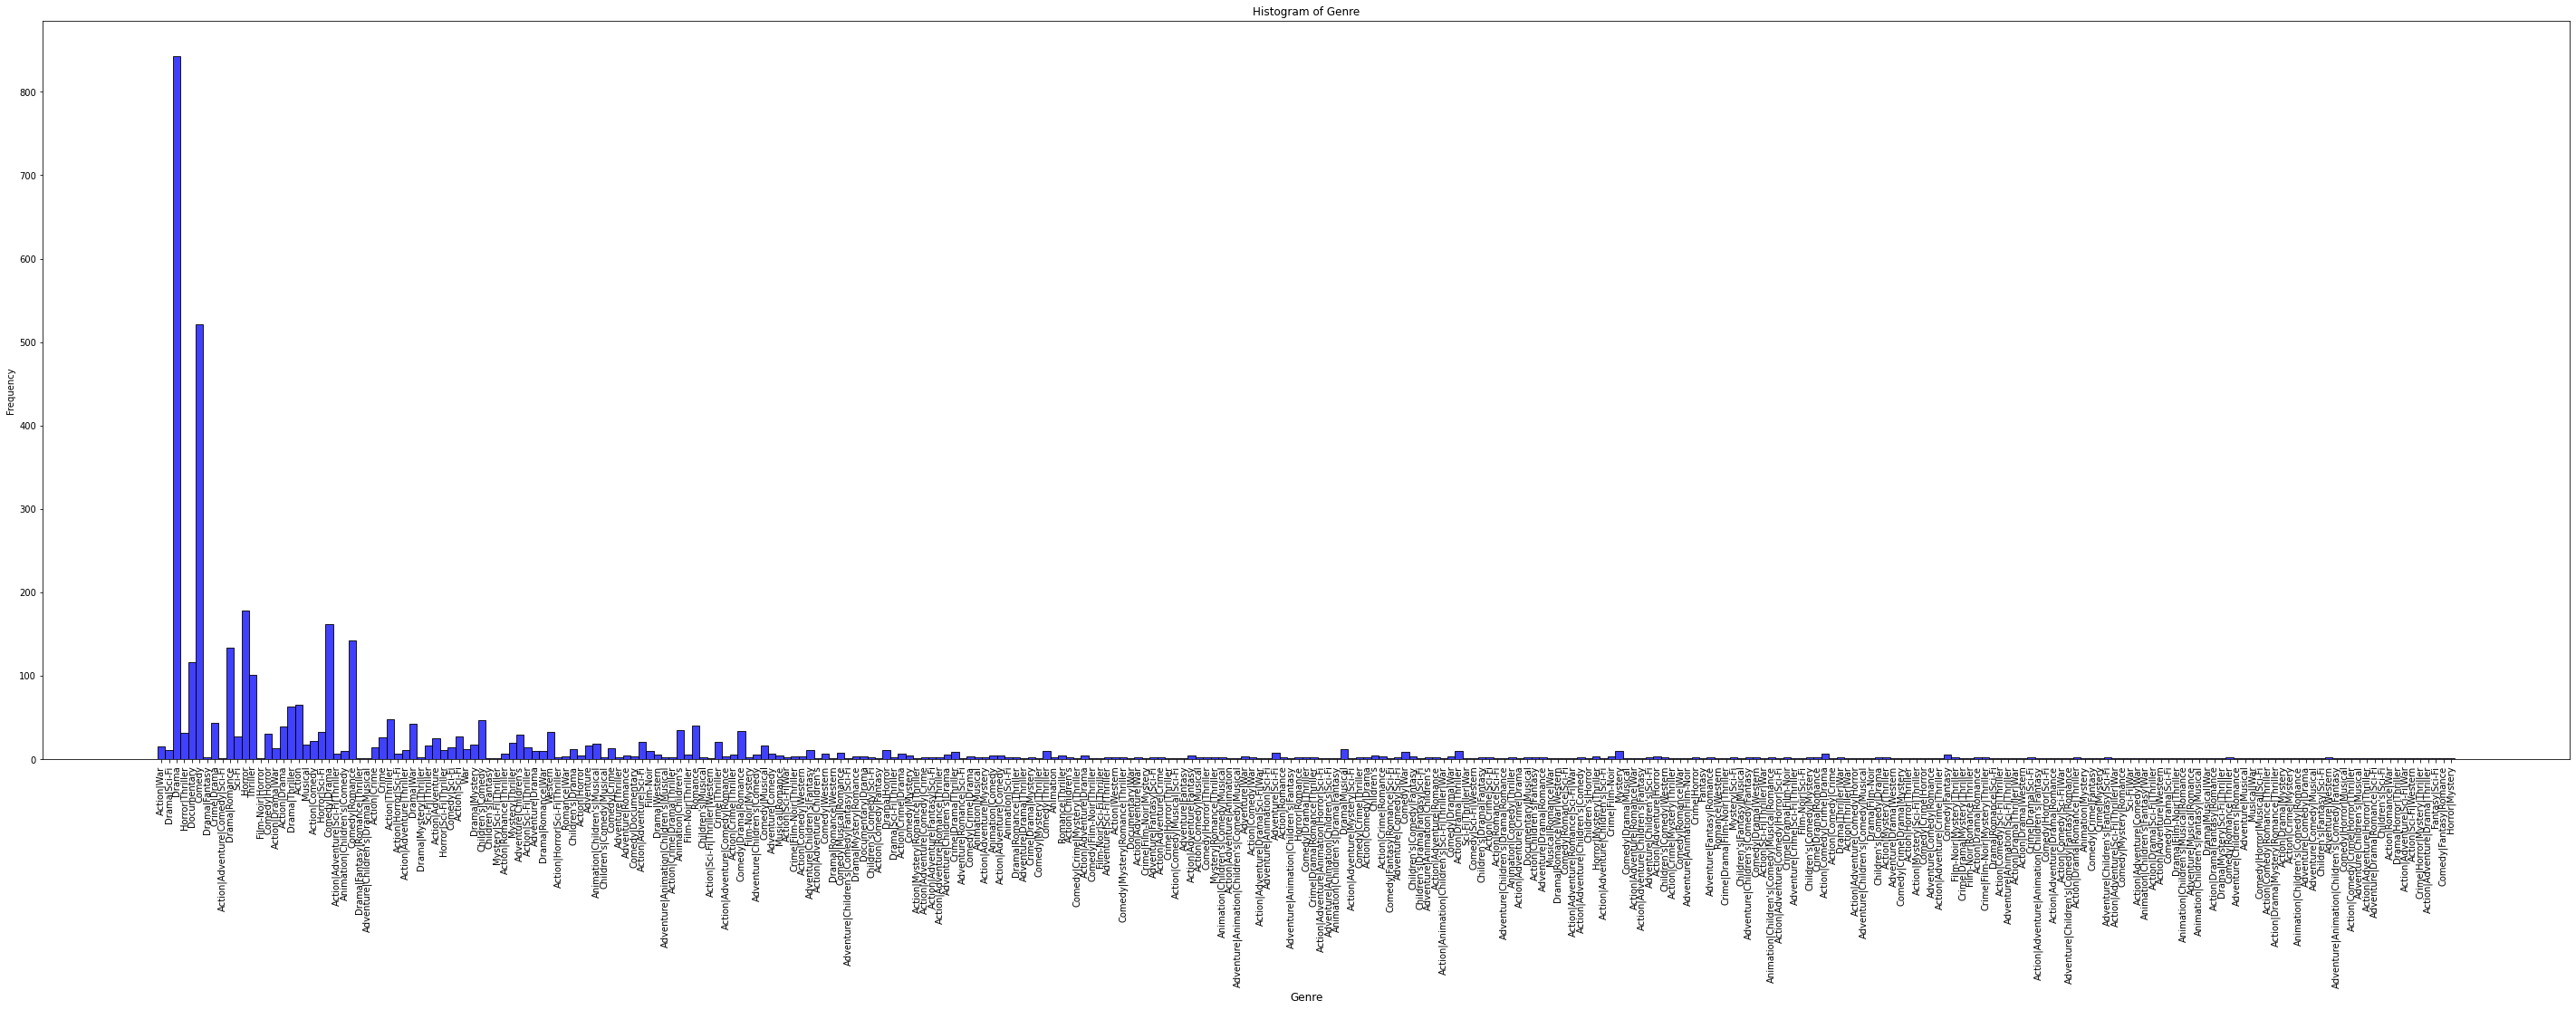

In [31]:
from matplotlib import pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(50, 15))
sns.histplot(x = 'Genre', data = df_movies, color = 'b' )
plt.xlabel('Genre', fontsize = 12)
plt.ylabel('Frequency')
plt.title('Histogram of Genre')
plt.xticks(rotation = 90,)
plt.show()

* Visualize the bar plot showing no.of movies released in a particular year

In [32]:
new = df_movies.Title.str.contains("LAssocie").any()
new

False

In [33]:
#s="400 Blows, The (Les Quatre cents coups) (1959)" "L'Associe1982"

yr = []
for s in df_movies['Title']:
    yr.append(s.split()[-1].replace('(','').replace(')','').replace(r'[a-zA-Z]','').replace('\'','').strip(' \t\n\r'))
df_movies['Year'] = yr
df_movies.tail()

,MovieID,Genre,Title,Year
3878,945,Comedy|Musical|Romance,Top Hat (1935),1935
3879,2490,Action|Thriller,Payback (1999),1999
3880,3405,Action|Drama,"Night to Remember, A (1958)",1958
3881,3476,Horror|Mystery|Thriller,Jacob's Ladder (1990),1990
3882,2542,Comedy|Crime|Thriller,"Lock, Stock & Two Smoking Barrels (1998)",1998


In [34]:
df_movies.groupby(['Year']).count()

,MovieID,Genre,Title
Year,,,
1919,3,3,3
1920,2,2,2
1921,1,1,1
1922,2,2,2
1923,3,3,3
...,...,...,...
1997,315,315,315
1998,337,337,337
1999,283,283,283


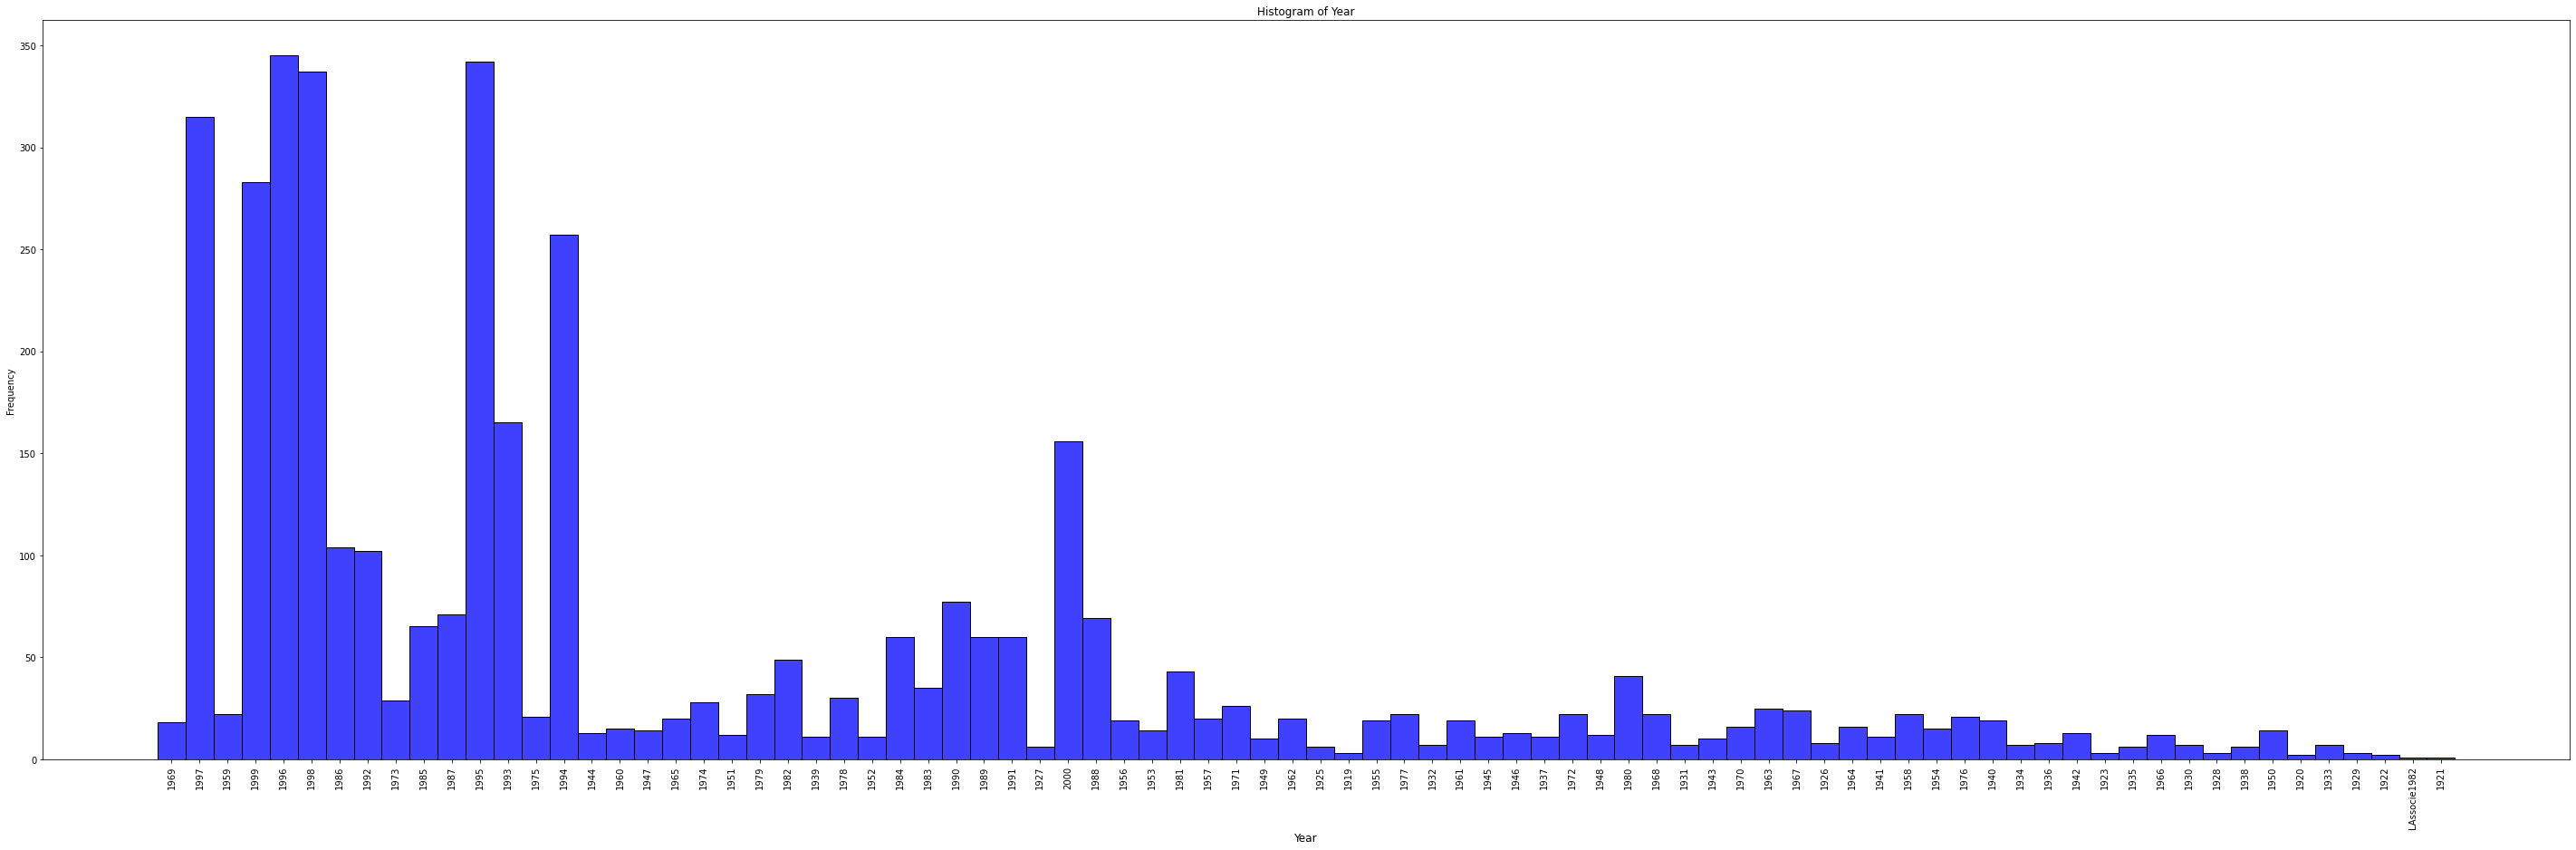

In [35]:
fig = plt.figure(figsize=(50, 15))
sns.histplot(x = 'Year', data = df_movies, color = 'b' )
plt.xlabel('Year', fontsize = 12)
plt.ylabel('Frequency')
plt.title('Histogram of Year')
plt.xticks(rotation = 90,)
plt.show()

* Depict the plot of Age groups ratio who are active in watching movies

In [36]:
result = []
query = "SELECT userid,age,gender FROM data_users"
rows = session.execute(query)
for row in rows:
    result.append([row[0], row[1], row[2]])
df_users = pd.DataFrame(result, columns=["UserID", "Age", "Gender"])

In [37]:
df_users.head()

,UserID,Age,Gender
0,4317,35,F
1,3372,56,M
2,1584,25,M
3,4830,1,M
4,2731,35,M


In [38]:
df_users.groupby(['Age']).count()

,UserID,Gender
Age,,
1,222,222
18,1103,1103
25,2096,2096
35,1193,1193
45,550,550
50,496,496
56,380,380


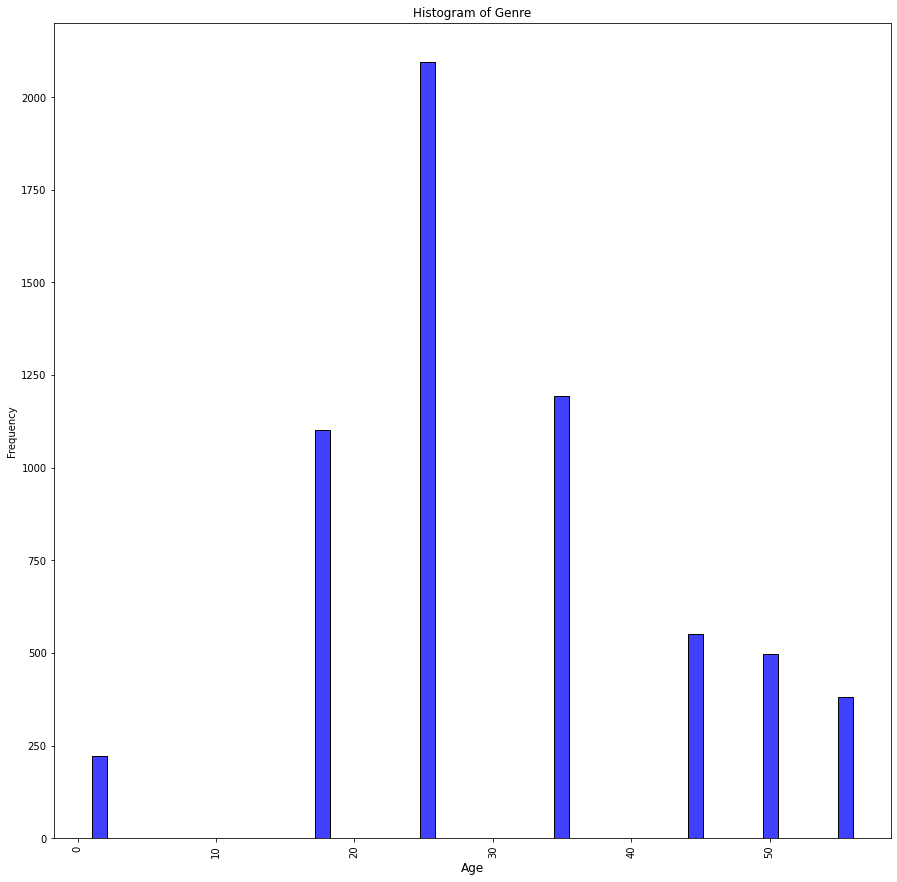

In [39]:
fig = plt.figure(figsize=(15, 15))
sns.histplot(x = 'Age', data = df_users, color = 'b' )
plt.xlabel('Age', fontsize = 12)
plt.ylabel('Frequency')
plt.title('Histogram of Genre')
plt.xticks(rotation = 90,)
plt.show()

### Analyzing the Data (3 points)

Analyzing the correlation between the movies records, implement a function to recommend movies based on search term

* Retrieve all the data from ratings table

In [49]:
result = []
query = "SELECT movieid,rating,userid FROM data_ratings"
rows = session.execute(query)
for row in rows:
    result.append([row[0], row[1], row[2]])
df_rating = pd.DataFrame(result, columns=["MovieID", "Rating", "UserID"])
df_rating.head()

,MovieID,Rating,UserID
0,3372,2,3589
1,3372,3,1470
2,3372,4,5390
3,3372,5,2203
4,1584,1,99


* Create a movie matrix by applying pivot table with the above retrieved ratings data

* use `pd.pivot_table` with index = `userid`, columns = `movieid` and Values = `rating`

 **Hint:** create a dataframe with above retrieved ratings data to apply pivot table

In [52]:
# Merging the movies, ratings dataframes
df_movies_ratings = pd.merge(df_movies, df_rating, on='MovieID')

In [53]:
df_movies_ratings.head()

,MovieID,Genre,Title,Year,Rating,UserID
0,3372,Action|War,"Bridge at Remagen, The (1969)",1969,2,3589
1,3372,Action|War,"Bridge at Remagen, The (1969)",1969,3,1470
2,3372,Action|War,"Bridge at Remagen, The (1969)",1969,4,5390
3,3372,Action|War,"Bridge at Remagen, The (1969)",1969,5,2203
4,1584,Drama|Sci-Fi,Contact (1997),1997,1,99


In [55]:
df_movies_ratings_users = pd.merge(df_movies_ratings, df_users, on='UserID')


In [56]:
df_movies_ratings_users.head()

,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender
0,3372,Action|War,"Bridge at Remagen, The (1969)",1969,2,3589,45,F
1,2786,Comedy,Haunted Honeymoon (1986),1986,2,3589,45,F
2,2896,Western,Alvarez Kelly (1966),1966,2,3589,45,F
3,2051,Adventure|Children's|Comedy,Herbie Goes to Monte Carlo (1977),1977,2,3589,45,F
4,234,Comedy,Exit to Eden (1994),1994,4,3589,45,F


* Define a function named `recommend_movies()` which will take a movieid as argument and return the top 5 similar movieid's

    * Considering the argument (movieid) as search item collect the particular row data
    
    * Using movie matrix calculate correlation between movie search Item data and all the remaining data
    
        * Hint: [corr_with()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corrwith.html)
        
    * Sort the result by ascending order and return the top 5 items

In [ ]:
# Ideas
# From movies table - Movie genre (link to other movies of same genre, year), From ratings table - rating (other movies of same rating), 
# From users table - age, gender (movies watched by people of same age, gender)

# Workflow 1 : Using the Genre, Age and Gender, find other movies watched by people of same age and gender in this genre. 
#              Select the top 5 based on AverageRating and closeness to Year 
# Workflow 2 : Select other movies of good rating in same genre. Select top 5 based on number of users.
# Workflow 3 : Select other movies of good rating in same year. Select top 5 based on number of users.
# Workflow 4 : https://blog.finxter.com/a-simple-recommendation-system-with-pandas/

In [146]:
# Workflow 1 : Using the Genre, Age and Gender, find other movies watched by people of same age and gender in this genre. 
#              Select the top 5 based on AvgRating and closeness to year
# Not using exact Year in query for Workflow 1 since in the same year, in same genre, multiple movies are not released
# Instead, filter based on closeness to the year.

#mid_query = movieId
mid_query = 1097

df_movies_partial_result = df_movies[df_movies.MovieID == mid_query]
print(df_movies_partial_result)

year_query = df_movies_partial_result.Year.astype(int).values[0]
genre_query = df_movies_partial_result.Genre.values[0]
title_query = df_movies_partial_result.Title.values[0]

print("We're interested in movies of genre: ", genre_query, " year:", year_query)

      MovieID                            Genre  \
1103     1097  Children's|Drama|Fantasy|Sci-Fi   

                                  Title  Year  
1103  E.T. the Extra-Terrestrial (1982)  1982  
We're interested in movies of genre:  Children's|Drama|Fantasy|Sci-Fi  year: 1982


In [147]:
uid_query = 1749 # Assuming the viewer was logged in as userid 1749 while running this query
df_users_partial_result = df_users[df_users.UserID == uid_query]
print(df_users_partial_result, "\n")

age_query = df_users_partial_result.Age.values[0]
gender_query = df_users_partial_result.Gender.values[0]

print("What did others of age: ", age_query, " and gender:", gender_query, " watch")

      UserID  Age Gender
3660    1749   25      M 

What did others of age:  25  and gender: M  watch


In [148]:
# Calculate the time period (Distance from the year eg '70s, '80s, '90s)
df_movies_ratings_users.Year = df_movies_ratings_users.Year.astype(int)
df_movies_ratings_users['NearToYear'] = df_movies_ratings_users.Year - year_query
df_movies_ratings_users.NearToYear = df_movies_ratings_users.NearToYear.abs()
df_movies_ratings_users

,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
0,3372,Action|War,"Bridge at Remagen, The (1969)",1969,2,3589,45,F,13,3.5,4
1,2786,Comedy,Haunted Honeymoon (1986),1986,2,3589,45,F,4,3.0,5
2,2896,Western,Alvarez Kelly (1966),1966,2,3589,45,F,16,3.0,5
3,2051,Adventure|Children's|Comedy,Herbie Goes to Monte Carlo (1977),1977,2,3589,45,F,5,3.0,5
4,234,Comedy,Exit to Eden (1994),1994,4,3589,45,F,12,3.0,5
...,...,...,...,...,...,...,...,...,...,...,...
16907,3809,Comedy,What About Bob? (1991),1991,4,3517,18,M,9,3.0,5
16908,1614,Comedy,In & Out (1997),1997,1,2494,18,M,15,3.0,5
16909,3405,Action|Drama,"Night to Remember, A (1958)",1958,2,3078,35,F,24,3.0,5
16910,3476,Horror|Mystery|Thriller,Jacob's Ladder (1990),1990,2,2142,45,F,8,3.0,5


In [149]:
df_movies_ratings_users_partial_result = df_movies_ratings_users[(df_movies_ratings_users.Age == age_query) & (df_movies_ratings_users.Gender == gender_query) & (df_movies_ratings_users.Genre.str.contains(genre_query))]
df_movies_ratings_users_partial_result

,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
172,1584,Drama|Sci-Fi,Contact (1997),1997,2,1794,25,M,15,3.0,5
173,2749,Drama|Mystery,"Morning After, The (1986)",1986,1,1794,25,M,4,3.0,5
176,1589,Crime|Drama|Mystery,Cop Land (1997),1997,3,1794,25,M,15,3.0,5
184,2731,Drama,"400 Blows, The (Les Quatre cents coups) (1959)",1959,1,1912,25,M,23,3.0,5
185,1940,Drama,Gentleman's Agreement (1947),1947,2,1912,25,M,35,3.5,4
...,...,...,...,...,...,...,...,...,...,...,...
16890,3933,Horror|Sci-Fi,"Killer Shrews, The (1959)",1959,2,1898,25,M,23,2.5,4
16898,800,Drama|Mystery,Lone Star (1996),1996,2,5155,25,M,14,3.0,5
16899,3386,Drama|Mystery,JFK (1991),1991,4,377,25,M,9,3.0,5
16902,3029,Action|Drama,Nighthawks (1981),1981,1,929,25,M,1,3.0,5


In [150]:
# Taking the Average Rating in the relevant partial result set. i.e average of rating by similar users instead of taking average Rating of all users
df_movies_ratings_users_partial_result['AvgRating'] = df_movies_ratings_users_partial_result['Rating'].groupby(df_movies_ratings_users_partial_result['MovieID']).transform('mean')
df_movies_ratings_users_partial_result

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
172,1584,Drama|Sci-Fi,Contact (1997),1997,2,1794,25,M,15,2.000000,5
173,2749,Drama|Mystery,"Morning After, The (1986)",1986,1,1794,25,M,4,2.500000,5
176,1589,Crime|Drama|Mystery,Cop Land (1997),1997,3,1794,25,M,15,3.000000,5
184,2731,Drama,"400 Blows, The (Les Quatre cents coups) (1959)",1959,1,1912,25,M,23,2.666667,5
185,1940,Drama,Gentleman's Agreement (1947),1947,2,1912,25,M,35,2.000000,4
...,...,...,...,...,...,...,...,...,...,...,...
16890,3933,Horror|Sci-Fi,"Killer Shrews, The (1959)",1959,2,1898,25,M,23,2.000000,4
16898,800,Drama|Mystery,Lone Star (1996),1996,2,5155,25,M,14,2.000000,5
16899,3386,Drama|Mystery,JFK (1991),1991,4,377,25,M,9,3.000000,5
16902,3029,Action|Drama,Nighthawks (1981),1981,1,929,25,M,1,2.000000,5


In [151]:
# Here, to recommend latest movies/new releases with relevance, we can descending sort by NearToYear
df_movies_ratings_users_sorted_result = df_movies_ratings_users_partial_result.sort_values(['NearToYear','AvgRating'],ascending=[True,False])
df_movies_ratings_users_sorted_result

,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
3898,2668,Horror|Sci-Fi,Swamp Thing (1982),1982,5,1680,25,M,0,5.0,5
2301,3543,Comedy|Drama,Diner (1982),1982,4,2780,25,M,0,4.5,5
2302,3543,Comedy|Drama,Diner (1982),1982,5,802,25,M,0,4.5,5
13609,2105,Action|Adventure|Fantasy|Sci-Fi,Tron (1982),1982,4,3182,25,M,0,4.5,5
16833,2105,Action|Adventure|Fantasy|Sci-Fi,Tron (1982),1982,5,4351,25,M,0,4.5,5
...,...,...,...,...,...,...,...,...,...,...,...
2410,3742,Drama|War,"Battleship Potemkin, The (Bronenosets Potyomki...",1925,3,3650,25,M,57,3.0,5
9823,3742,Drama|War,"Battleship Potemkin, The (Bronenosets Potyomki...",1925,4,3683,25,M,57,3.0,5
11506,3742,Drama|War,"Battleship Potemkin, The (Bronenosets Potyomki...",1925,1,937,25,M,57,3.0,5
11530,3742,Drama|War,"Battleship Potemkin, The (Bronenosets Potyomki...",1925,5,3167,25,M,57,3.0,5


In [152]:
df_movies_ratings_users_sorted_result = df_movies_ratings_users_sorted_result.drop_duplicates(subset=['MovieID'])
df_movies_ratings_users_sorted_result

,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
3898,2668,Horror|Sci-Fi,Swamp Thing (1982),1982,5,1680,25,M,0,5.000000,5
2301,3543,Comedy|Drama,Diner (1982),1982,4,2780,25,M,0,4.500000,5
13609,2105,Action|Adventure|Fantasy|Sci-Fi,Tron (1982),1982,4,3182,25,M,0,4.500000,5
3984,3592,Animation|Sci-Fi,Time Masters (Les Ma�tres du Temps) (1982),1982,4,5468,25,M,0,4.000000,3
5096,774,Drama,Wend Kuuni (God's Gift) (1982),1982,4,195,25,M,0,4.000000,1
...,...,...,...,...,...,...,...,...,...,...,...
3472,1925,Drama|Romance|War,Wings (1927),1927,2,169,25,M,55,2.000000,5
6945,2010,Sci-Fi,Metropolis (1926),1926,5,6040,25,M,56,3.333333,5
2591,957,Drama,"Scarlet Letter, The (1926)",1926,2,4959,25,M,56,2.000000,5
235,3742,Drama|War,"Battleship Potemkin, The (Bronenosets Potyomki...",1925,2,1912,25,M,57,3.000000,5


In [153]:
# Select top 5
df_workflow_1_result = df_movies_ratings_users_sorted_result.head(5)
print("Others like you watched: \n")
df_workflow_1_result

Others like you watched: 



,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
3898,2668,Horror|Sci-Fi,Swamp Thing (1982),1982,5,1680,25,M,0,5.0,5
2301,3543,Comedy|Drama,Diner (1982),1982,4,2780,25,M,0,4.5,5
13609,2105,Action|Adventure|Fantasy|Sci-Fi,Tron (1982),1982,4,3182,25,M,0,4.5,5
3984,3592,Animation|Sci-Fi,Time Masters (Les Ma�tres du Temps) (1982),1982,4,5468,25,M,0,4.0,3
5096,774,Drama,Wend Kuuni (God's Gift) (1982),1982,4,195,25,M,0,4.0,1


In [154]:
# Workflow 2
df_movies_ratings_users_partial_result_wf2 = df_movies_ratings_users[(df_movies_ratings_users.Genre.str.contains(genre_query))]
df_movies_ratings_users_partial_result_wf2

,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
3,2051,Adventure|Children's|Comedy,Herbie Goes to Monte Carlo (1977),1977,2,3589,45,F,5,3.0,5
5,293,Crime|Drama|Romance|Thriller,"Professional, The (a.k.a. Leon: The Profession...",1994,1,3589,45,F,12,3.0,5
6,2928,Drama,"Razor's Edge, The (1984)",1984,1,3589,45,F,2,3.0,5
9,1620,Crime|Drama|Thriller,Kiss the Girls (1997),1997,1,3589,45,F,15,3.0,5
10,458,Drama|Western,Geronimo: An American Legend (1993),1993,1,3589,45,F,11,3.0,5
...,...,...,...,...,...,...,...,...,...,...,...
16901,2100,Comedy|Fantasy|Romance,Splash (1984),1984,4,4687,35,M,2,3.0,5
16902,3029,Action|Drama,Nighthawks (1981),1981,1,929,25,M,1,3.0,5
16903,3029,Action|Drama,Nighthawks (1981),1981,3,3815,25,M,1,3.0,5
16906,232,Comedy|Drama,Eat Drink Man Woman (1994),1994,5,1542,18,M,12,3.0,5


In [155]:
# Taking the Average Rating in the relevant partial result set. i.e average of rating by all users (not necessarily similar users)
df_movies_ratings_users_partial_result_wf2['AvgRating'] = df_movies_ratings_users_partial_result_wf2['Rating'].groupby(df_movies_ratings_users_partial_result_wf2['MovieID']).transform('mean')
df_movies_ratings_users_partial_result_wf2

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
3,2051,Adventure|Children's|Comedy,Herbie Goes to Monte Carlo (1977),1977,2,3589,45,F,5,3.0,5
5,293,Crime|Drama|Romance|Thriller,"Professional, The (a.k.a. Leon: The Profession...",1994,1,3589,45,F,12,3.0,5
6,2928,Drama,"Razor's Edge, The (1984)",1984,1,3589,45,F,2,3.0,5
9,1620,Crime|Drama|Thriller,Kiss the Girls (1997),1997,1,3589,45,F,15,3.0,5
10,458,Drama|Western,Geronimo: An American Legend (1993),1993,1,3589,45,F,11,3.0,5
...,...,...,...,...,...,...,...,...,...,...,...
16901,2100,Comedy|Fantasy|Romance,Splash (1984),1984,4,4687,35,M,2,3.0,5
16902,3029,Action|Drama,Nighthawks (1981),1981,1,929,25,M,1,3.0,5
16903,3029,Action|Drama,Nighthawks (1981),1981,3,3815,25,M,1,3.0,5
16906,232,Comedy|Drama,Eat Drink Man Woman (1994),1994,5,1542,18,M,12,3.0,5


In [156]:
# Count number of users who have watched a certain movie (viewership)
df_movies_ratings_users_partial_result_wf2['NumUsers'] = df_movies_ratings_users_partial_result_wf2.groupby('MovieID')['MovieID'].transform('size')
df_movies_ratings_users_partial_result_wf2

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
3,2051,Adventure|Children's|Comedy,Herbie Goes to Monte Carlo (1977),1977,2,3589,45,F,5,3.0,5
5,293,Crime|Drama|Romance|Thriller,"Professional, The (a.k.a. Leon: The Profession...",1994,1,3589,45,F,12,3.0,5
6,2928,Drama,"Razor's Edge, The (1984)",1984,1,3589,45,F,2,3.0,5
9,1620,Crime|Drama|Thriller,Kiss the Girls (1997),1997,1,3589,45,F,15,3.0,5
10,458,Drama|Western,Geronimo: An American Legend (1993),1993,1,3589,45,F,11,3.0,5
...,...,...,...,...,...,...,...,...,...,...,...
16901,2100,Comedy|Fantasy|Romance,Splash (1984),1984,4,4687,35,M,2,3.0,5
16902,3029,Action|Drama,Nighthawks (1981),1981,1,929,25,M,1,3.0,5
16903,3029,Action|Drama,Nighthawks (1981),1981,3,3815,25,M,1,3.0,5
16906,232,Comedy|Drama,Eat Drink Man Woman (1994),1994,5,1542,18,M,12,3.0,5


In [157]:
df_movies_ratings_users_sorted_result_wf2 = df_movies_ratings_users_partial_result_wf2.sort_values(["NumUsers","AvgRating"],ascending=[False,False])
df_movies_ratings_users_sorted_result_wf2

,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
3,2051,Adventure|Children's|Comedy,Herbie Goes to Monte Carlo (1977),1977,2,3589,45,F,5,3.0,5
5,293,Crime|Drama|Romance|Thriller,"Professional, The (a.k.a. Leon: The Profession...",1994,1,3589,45,F,12,3.0,5
6,2928,Drama,"Razor's Edge, The (1984)",1984,1,3589,45,F,2,3.0,5
9,1620,Crime|Drama|Thriller,Kiss the Girls (1997),1997,1,3589,45,F,15,3.0,5
10,458,Drama|Western,Geronimo: An American Legend (1993),1993,1,3589,45,F,11,3.0,5
...,...,...,...,...,...,...,...,...,...,...,...
9858,1165,Drama|Thriller,"Bloody Child, The (1996)",1996,1,293,56,M,14,1.0,1
10026,2845,Drama,White Boys (1999),1999,1,5780,18,M,17,1.0,1
12934,826,Drama,Diebinnen (1995),1995,1,87,25,M,13,1.0,1
15276,3209,Drama,"Loves of Carmen, The (1948)",1948,1,992,35,F,34,1.0,1


In [158]:
df_movies_ratings_users_sorted_result_wf2 = df_movies_ratings_users_sorted_result_wf2.drop_duplicates(subset=['MovieID'])
df_movies_ratings_users_sorted_result_wf2

,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
3,2051,Adventure|Children's|Comedy,Herbie Goes to Monte Carlo (1977),1977,2,3589,45,F,5,3.0,5
5,293,Crime|Drama|Romance|Thriller,"Professional, The (a.k.a. Leon: The Profession...",1994,1,3589,45,F,12,3.0,5
6,2928,Drama,"Razor's Edge, The (1984)",1984,1,3589,45,F,2,3.0,5
9,1620,Crime|Drama|Thriller,Kiss the Girls (1997),1997,1,3589,45,F,15,3.0,5
10,458,Drama|Western,Geronimo: An American Legend (1993),1993,1,3589,45,F,11,3.0,5
...,...,...,...,...,...,...,...,...,...,...,...
9858,1165,Drama|Thriller,"Bloody Child, The (1996)",1996,1,293,56,M,14,1.0,1
10026,2845,Drama,White Boys (1999),1999,1,5780,18,M,17,1.0,1
12934,826,Drama,Diebinnen (1995),1995,1,87,25,M,13,1.0,1
15276,3209,Drama,"Loves of Carmen, The (1948)",1948,1,992,35,F,34,1.0,1


In [159]:
# Select top 5
df_workflow_2_result = df_movies_ratings_users_sorted_result_wf2.head(5)
print("Because you watched ", title_query, "\n")
df_workflow_2_result

Because you watched  E.T. the Extra-Terrestrial (1982) 



,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
3,2051,Adventure|Children's|Comedy,Herbie Goes to Monte Carlo (1977),1977,2,3589,45,F,5,3.0,5
5,293,Crime|Drama|Romance|Thriller,"Professional, The (a.k.a. Leon: The Profession...",1994,1,3589,45,F,12,3.0,5
6,2928,Drama,"Razor's Edge, The (1984)",1984,1,3589,45,F,2,3.0,5
9,1620,Crime|Drama|Thriller,Kiss the Girls (1997),1997,1,3589,45,F,15,3.0,5
10,458,Drama|Western,Geronimo: An American Legend (1993),1993,1,3589,45,F,11,3.0,5


In [160]:
# Workflow 3 
df_movies_ratings_users_partial_result_wf3 = df_movies_ratings_users

# Taking the Average Rating from all users (not necessarily similar users)
df_movies_ratings_users_partial_result_wf3['AvgRating'] = df_movies_ratings_users_partial_result_wf3['Rating'].groupby(df_movies_ratings_users_partial_result_wf3['MovieID']).transform('mean')
df_movies_ratings_users_partial_result_wf3

,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
0,3372,Action|War,"Bridge at Remagen, The (1969)",1969,2,3589,45,F,13,3.5,4
1,2786,Comedy,Haunted Honeymoon (1986),1986,2,3589,45,F,4,3.0,5
2,2896,Western,Alvarez Kelly (1966),1966,2,3589,45,F,16,3.0,5
3,2051,Adventure|Children's|Comedy,Herbie Goes to Monte Carlo (1977),1977,2,3589,45,F,5,3.0,5
4,234,Comedy,Exit to Eden (1994),1994,4,3589,45,F,12,3.0,5
...,...,...,...,...,...,...,...,...,...,...,...
16907,3809,Comedy,What About Bob? (1991),1991,4,3517,18,M,9,3.0,5
16908,1614,Comedy,In & Out (1997),1997,1,2494,18,M,15,3.0,5
16909,3405,Action|Drama,"Night to Remember, A (1958)",1958,2,3078,35,F,24,3.0,5
16910,3476,Horror|Mystery|Thriller,Jacob's Ladder (1990),1990,2,2142,45,F,8,3.0,5


In [161]:
# Count number of users who have watched a certain movie (viewership)
df_movies_ratings_users_partial_result_wf3['NumUsers'] = df_movies_ratings_users_partial_result_wf3.groupby('MovieID')['MovieID'].transform('size')
df_movies_ratings_users_partial_result_wf3

,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
0,3372,Action|War,"Bridge at Remagen, The (1969)",1969,2,3589,45,F,13,3.5,4
1,2786,Comedy,Haunted Honeymoon (1986),1986,2,3589,45,F,4,3.0,5
2,2896,Western,Alvarez Kelly (1966),1966,2,3589,45,F,16,3.0,5
3,2051,Adventure|Children's|Comedy,Herbie Goes to Monte Carlo (1977),1977,2,3589,45,F,5,3.0,5
4,234,Comedy,Exit to Eden (1994),1994,4,3589,45,F,12,3.0,5
...,...,...,...,...,...,...,...,...,...,...,...
16907,3809,Comedy,What About Bob? (1991),1991,4,3517,18,M,9,3.0,5
16908,1614,Comedy,In & Out (1997),1997,1,2494,18,M,15,3.0,5
16909,3405,Action|Drama,"Night to Remember, A (1958)",1958,2,3078,35,F,24,3.0,5
16910,3476,Horror|Mystery|Thriller,Jacob's Ladder (1990),1990,2,2142,45,F,8,3.0,5


In [162]:
# Here, to recommend latest movies/new releases "Now trending" with relevance, we can descending sort by NearToYear
df_movies_ratings_users_sorted_result_wf3 = df_movies_ratings_users.sort_values(['NearToYear','NumUsers','AvgRating'],ascending=[True,False,False])
df_movies_ratings_users_sorted_result_wf3

,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
100,2512,Drama,"Ballad of Narayama, The (Narayama Bushiko) (1982)",1982,2,1470,18,M,0,3.0,5
299,541,Film-Noir|Sci-Fi,Blade Runner (1982),1982,5,4041,18,M,0,3.0,5
320,3431,Action|Drama,Death Wish II (1982),1982,2,3778,25,M,0,3.0,5
488,2104,Drama,Tex (1982),1982,1,117,25,M,0,3.0,5
971,3221,Drama,"Draughtsman's Contract, The (1982)",1982,2,4473,35,M,0,3.0,5
...,...,...,...,...,...,...,...,...,...,...,...
2915,2823,Action|Drama,"Spiders, The (Die Spinnen, 1. Teil: Der Golden...",1919,5,3539,25,F,63,3.0,3
5440,2823,Action|Drama,"Spiders, The (Die Spinnen, 1. Teil: Der Golden...",1919,3,1140,45,F,63,3.0,3
10054,2823,Action|Drama,"Spiders, The (Die Spinnen, 1. Teil: Der Golden...",1919,1,2665,35,M,63,3.0,3
825,2821,Adventure|Drama,Male and Female (1919),1919,4,4169,50,M,63,3.0,2


In [163]:
df_movies_ratings_users_sorted_result_wf3 = df_movies_ratings_users_sorted_result_wf3.drop_duplicates(subset=['MovieID'])
df_movies_ratings_users_sorted_result_wf3

,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
100,2512,Drama,"Ballad of Narayama, The (Narayama Bushiko) (1982)",1982,2,1470,18,M,0,3.0,5
299,541,Film-Noir|Sci-Fi,Blade Runner (1982),1982,5,4041,18,M,0,3.0,5
320,3431,Action|Drama,Death Wish II (1982),1982,2,3778,25,M,0,3.0,5
488,2104,Drama,Tex (1982),1982,1,117,25,M,0,3.0,5
971,3221,Drama,"Draughtsman's Contract, The (1982)",1982,2,4473,35,M,0,3.0,5
...,...,...,...,...,...,...,...,...,...,...,...
1077,3310,Action,"Kid, The (1921)",1921,5,4277,35,M,61,3.0,5
874,3309,Comedy,"Dog's Life, A (1920)",1920,5,4169,50,M,62,3.0,5
478,3132,Comedy,Daddy Long Legs (1919),1919,3,411,45,F,63,3.0,5
2915,2823,Action|Drama,"Spiders, The (Die Spinnen, 1. Teil: Der Golden...",1919,5,3539,25,F,63,3.0,3


In [164]:
# Select top 5
df_workflow_3_result = df_movies_ratings_users_sorted_result_wf3.head(5)
print("Because you watched ", title_query, "\n")
df_workflow_3_result

Because you watched  E.T. the Extra-Terrestrial (1982) 



,MovieID,Genre,Title,Year,Rating,UserID,Age,Gender,NearToYear,AvgRating,NumUsers
100,2512,Drama,"Ballad of Narayama, The (Narayama Bushiko) (1982)",1982,2,1470,18,M,0,3.0,5
299,541,Film-Noir|Sci-Fi,Blade Runner (1982),1982,5,4041,18,M,0,3.0,5
320,3431,Action|Drama,Death Wish II (1982),1982,2,3778,25,M,0,3.0,5
488,2104,Drama,Tex (1982),1982,1,117,25,M,0,3.0,5
971,3221,Drama,"Draughtsman's Contract, The (1982)",1982,2,4473,35,M,0,3.0,5


In [ ]:
recommend_movie(1097)

In [ ]:
#def recommend_movie(movieId):
#  rows = session.execute("select * from data_movies where movieid = $[movieId]")
#  if rows:
#      for movie_row in rows:
#        print(movie_row[0], movie_row[1], movie_row[2])
#  else:
#      print("An error occurred.")

* write a query to get MovieId of a Title (your choice) and the result MovieId as a search item by calling the above defined function

In [ ]:
#title_of_choice = "E.T. the Extra-Terrestrial (1982)"
#movieId = session.execute("select movieId from data_movies where title = $[title_of_choice]") # use "like" for matching title if year is not in title
#if movieId:
#    print(movieId)
#else:
#    print("An error occurred.")

#top5_movies = recommend_movie(movieId)

* Now taking the resulf of top 5 items (MovieId's) write a query to retrieve the Movie title from movies table

In [ ]:
#movie_titles = []

#for id in top5_movies:
#  movie_title = session.execute("select title from data_movies where movieid = $[id]")
#  if movie_title:
#    print(movie_title)
#    movie_titles.append(movie_title)
#  else:
#    print("An error occurred.")

#movie_titles

**Workflow 1 Result**

**MovieID	Genre	Title	Year	Rating	UserID	Age	Gender	NearToYear	AvgRating	NumUsers**
3898	2668	Horror|Sci-Fi	Swamp Thing (1982)	1982	5	1680	25	M	0	5.0	5
2301	3543	Comedy|Drama	Diner (1982)	1982	4	2780	25	M	0	4.5	5
13609	2105	Action|Adventure|Fantasy|Sci-Fi	Tron (1982)	1982	4	3182	25	M	0	4.5	5
3984	3592	Animation|Sci-Fi	Time Masters (Les Ma�tres du Temps) (1982)	1982	4	5468	25	M	0	4.0	3
5096	774	Drama	Wend Kuuni (God's Gift) (1982)	1982	4	195	25	M	0	4.0	1

**Workflow 2 Result**

**MovieID	Genre	Title	Year	Rating	UserID	Age	Gender	NearToYear	AvgRating	NumUsers**
3	2051	Adventure|Children's|Comedy	Herbie Goes to Monte Carlo (1977)	1977	2	3589	45	F	5	3.0	5
5	293	Crime|Drama|Romance|Thriller	Professional, The (a.k.a. Leon: The Profession...	1994	1	3589	45	F	12	3.0	5
6	2928	Drama	Razor's Edge, The (1984)	1984	1	3589	45	F	2	3.0	5
9	1620	Crime|Drama|Thriller	Kiss the Girls (1997)	1997	1	3589	45	F	15	3.0	5
10	458	Drama|Western	Geronimo: An American Legend (1993)	1993	1	3589	45	F	11	3.0	5

**Workflow 3 Result**

**MovieID	Genre	Title	Year	Rating	UserID	Age	Gender	NearToYear	AvgRating	NumUsers**
100	2512	Drama	Ballad of Narayama, The (Narayama Bushiko) (1982)	1982	2	1470	18	M	0	3.0	5
299	541	Film-Noir|Sci-Fi	Blade Runner (1982)	1982	5	4041	18	M	0	3.0	5
320	3431	Action|Drama	Death Wish II (1982)	1982	2	3778	25	M	0	3.0	5
488	2104	Drama	Tex (1982)	1982	1	117	25	M	0	3.0	5
971	3221	Drama	Draughtsman's Contract, The (1982)	1982	2	4473	35	M	0	3.0	5